# AMERICAN PUT OPTION WITH MONTE CARLO

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy


## First Test on European Puts

In [2]:

def paths(S0, r, q, sig, T, M, N):
    """(N, M+1) array of GBM paths, exact stepping, antithetic."""
    dt = T/M
    Z = np.random.randn(N//2, M)
    Z = np.concatenate([Z, -Z], axis=0)
    incr = (r - q - 0.5*sig**2)*dt + sig*np.sqrt(dt)*Z

    logS = np.zeros((N, M+1))
    logS[:, 0]  = np.log(S0)
    logS[:, 1:] = np.log(S0) + np.cumsum(incr, axis=1)
    S = np.exp(logS)

    return S


def price(S_at_T, K, r, T): #S_at_T will be the last column of all the walkers S[:, -1]
    v = np.exp(-r*T)*np.maximum(K - S_at_T , 0)
    return v.mean(), v.std(ddof=1)/np.sqrt(len(v))

In [3]:
T = 1.
S0 = 1.
r = 0.05
sigma = 0.20
q = 0.0
K = 1.

In [4]:

#array for number of samples
N = np.array([100,500,1000,5000,10000,50000,100000,500000,1000000])

In [5]:
european_put_payoffs = np.zeros((len(N),2))

for i in range(0, len(N)):
    european_put_payoffs[i,:] = price(paths(S0, r, q, sigma, T, 10, N[i])[:, -1], K,  r, T)

In [8]:
def euro_put(x, tau, K, r, q, sig):
   
    d2 = (x + (r - 0.5*sig**2)*tau) / (sig*np.sqrt(tau))
    d1 = d2 + sig*np.sqrt(tau)
    return -np.exp(-q*tau)*K*np.exp(x)*scipy.stats.norm.cdf(-d1) + K*np.exp(-r*tau)*scipy.stats.norm.cdf(-d2)

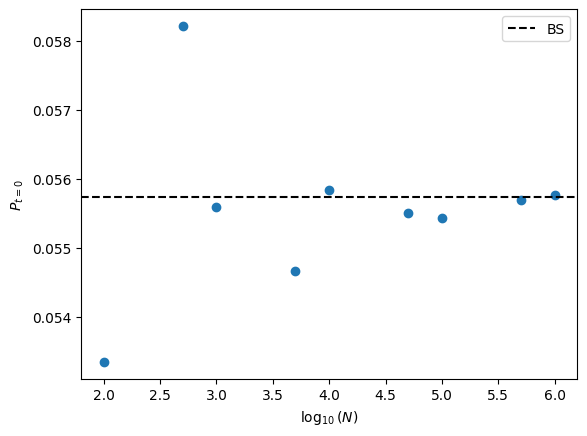

In [10]:
plt.scatter(np.log10(N), european_put_payoffs[:,0])
plt.axhline(y = euro_put(np.log(S0/K),T,K,r,q,sigma), c='black', linestyle='dashed', label ='BS')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$P_{t=0}$')
plt.legend()
plt.show()

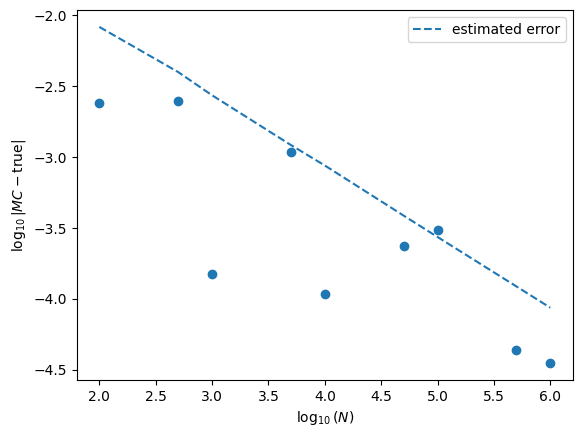

In [11]:
plt.scatter(np.log10(N), np.log10(np.abs(european_put_payoffs[:,0] - euro_put(np.log(S0/K),T,K,r,q,sigma))))
plt.plot(np.log10(N), np.log10(np.abs(european_put_payoffs[:,1])), label ='estimated error', linestyle='dashed')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$\log_{10}|{MC-\text{true}}|$')
plt.legend()
plt.show()

## Now do American Put Option

In [36]:
def lsm_put(S, K, r, T, deg=3):
    N, M = S.shape[0], S.shape[1]-1
    dt = T/M
    df = np.exp(-r*dt)
    cf = np.maximum(K - S[:, -1], 0.0)          # cashflow, at tau = 0/terminal point
    for i in range(M-1, 0, -1): #stop at t1, because at t0, regression is degenerate!
        cf *= df                                 # cashflow rolled back
        itm = K - S[:, i] > 0                     #walkers that are exercisable
        if itm.sum() < deg + 2:     #if too few indices, skip to next step
            continue
        beta = np.polyfit(S[itm, i], cf[itm], deg) #fit for cashflow(stock price)
        cont = np.polyval(beta, S[itm, i])  #evaluate continuum cashflow(stock price)
        ex   = K - S[itm, i]                 #exercise value
        take = ex > cont                    #indices that are good to exercise

        #indexing hoopla
        idx  = np.where(itm)[0][take]
        cf[idx] = ex[take]

    v = np.exp(-r*dt)*cf #discount to t=0 from t=1
    return v.mean(), v.std(ddof=1)/np.sqrt(len(v))


In [37]:
truth = 0.06086084642948057

## Shallow M, deg = 3, N convergence

In [35]:
american_put_payoffs = np.zeros((len(N),2))

for i in range(0, len(N)):
    american_put_payoffs[i,:] = lsm_put(paths(S0, r, q, sigma, T, 10, N[i]) , K, r, T, 3)

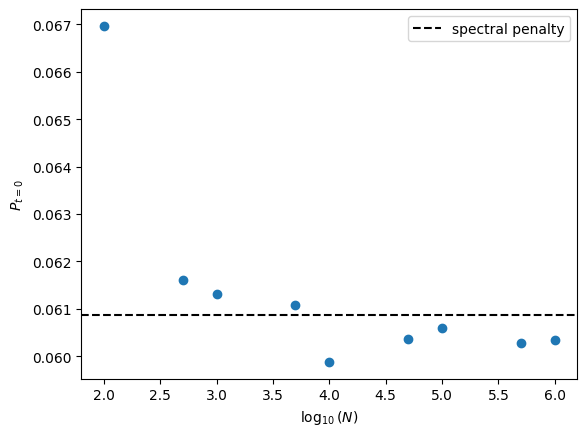

In [36]:
plt.scatter(np.log10(N), american_put_payoffs[:,0])
plt.axhline(y=truth, c='black', linestyle='dashed', label ='spectral penalty')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$P_{t=0}$')
plt.legend()
plt.show()

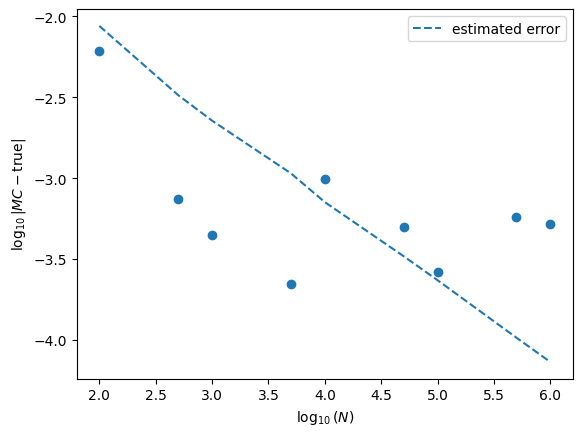

In [37]:
plt.scatter(np.log10(N), np.log10(np.abs(american_put_payoffs[:,0] - truth)))
plt.plot(np.log10(N), np.log10(np.abs(american_put_payoffs[:,1])), label ='estimated error', linestyle='dashed')
plt.xlabel(r'$\log_{10}(N)$')
plt.ylabel(r'$\log_{10}|{MC-\text{true}}|$')
plt.legend()
plt.show()

## High N, deg = 3, M Convergence

In [38]:
M = np.array([10,20,30,40,50])

In [39]:
american_put_payoffs = np.zeros((len(M),2))

for i in range(0, len(M)):
    american_put_payoffs[i,:] = lsm_put(paths(S0, r, q, sigma, T, M[i], N[-1]) , K, r, T, 3)

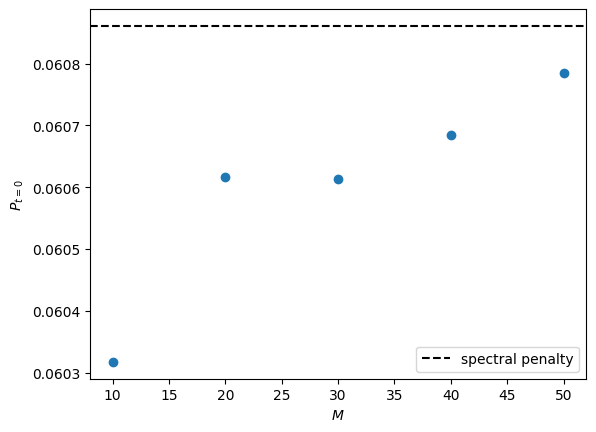

In [40]:
plt.scatter(M, american_put_payoffs[:,0])
plt.axhline(y=truth, c='black', linestyle='dashed', label ='spectral penalty')
plt.xlabel(r'$M$')
plt.ylabel(r'$P_{t=0}$')
plt.legend()
plt.show()

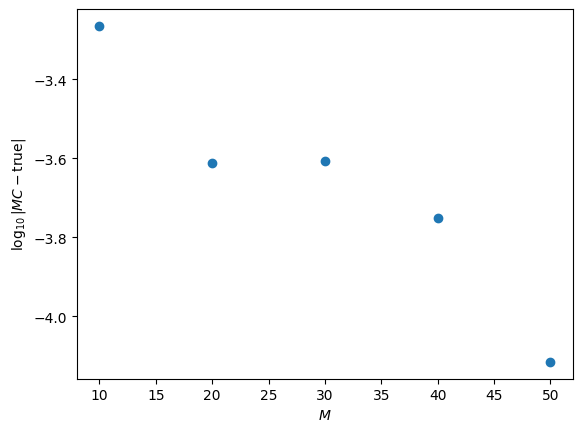

In [42]:
plt.scatter(M, np.log10(np.abs(american_put_payoffs[:,0] - truth)))
plt.xlabel(r'$M$')
plt.ylabel(r'$\log_{10}|{MC-\text{true}}|$')
plt.show()

Number of steps is more so the limiting factor, compared to number of walkers.

## Movie

In [39]:
stock_data = paths(S0, r, q, sigma, T, 50, 1000)

In [92]:
def lsm_put_movie(S, K, r, T, deg=3):
    N, M = S.shape[0], S.shape[1]-1
    dt = T/M
    df = np.exp(-r*dt)
    cf = np.zeros((N, M+1))
    cf[:, M] = np.maximum(K - S[:, -1], 0.0)   # cashflow, at tau = 0/terminal point

    exd = np.zeros((N, M+1), dtype=bool)          # <-- exercise decision container
    exd[:, M] = K - S[:, -1] > 0                  # <-- ITM at maturity = exercised

    for i in range(M-1, 0, -1): #stop at t1, because at t0, regression is degenerate!
        cf[:, i] = cf[:, i+1]*df                     # cashflow rolled back
        itm = K - S[:, i] > 0                     #walkers that are exercisable
        if itm.sum() < deg + 2:     #if too few indices, skip to next step
            continue
        beta = np.polyfit(S[itm, i], cf[itm, i], deg) #fit for cashflow(stock price)
        cont = np.polyval(beta, S[itm, i])  #evaluate continuum cashflow(stock price)
        ex   = K - S[itm, i]                 #exercise value
        take = ex > cont                    #indices that are good to exercise

        #indexing hoopla
        idx= np.where(itm)[0][take]
        cf[idx, i] = ex[take]
        exd[idx, i] = True                        # <-- same indices, same place

    cf[:, 0] = np.exp(-r*dt)*cf[:,1] #discount to t=0 from t=1
    itm = K - S[:, 0] > 0 
    ex   = K - S[itm, 0]                 #exercise value
    take = ex > cf[itm,0]                    #indices that are good to exercise

    #indexing hoopla
    idx= np.where(itm)[0][take]
    cf[idx, 0] = ex[take]
    exd[idx, 0] = True                        # <-- same indices, same place

    return cf, exd, cf[:,0].mean(), cf[:,0].std(ddof=1)/np.sqrt(len(cf))
 

In [93]:
lsm_data = lsm_put_movie(stock_data, K, r, T, 3)

In [94]:
cf_data, exd_data = lsm_data[0], lsm_data[1]

In [95]:
lsm_data[2]

0.062441312028729164

In [68]:
def plot_frame_phase1(index, ax):
    ax.scatter(K - stock_data[:, index], np.repeat(index, 1000), c='yellow', s=1)

    ax.axvline(x=0, c='red', linestyle='dashed')

    ax.set_ylim([-0.25,52.5])
    ax.set_xlim([np.min(K - stock_data[:, -1])*1.1, np.max(K - stock_data[:, -1])*1.1 ])

    ax.tick_params(colors='white')
    ax.set_xlabel(r'$\text{Strike}(K)-\text{Stock}(S)$', c='white', fontsize=15)
    ax.set_ylabel('Time Slice', c='white', fontsize=15)
    ax.set_title('Phase 1: Evolve Walkers with GBM', c='white', fontsize=20)
    ax.grid(linewidth=0.5)
    

    



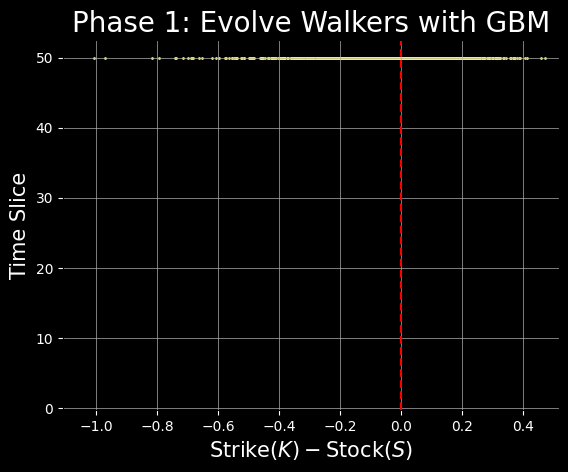

In [69]:
fig, ax = plt.subplots()
fig.set_facecolor('black')
ax.set_facecolor('black')
plot_frame_phase1(50,ax)
plt.show()

In [99]:
def plot_frame_phase2(index, ax):
    M = stock_data.shape[1]-1
    for j in range(index, M+1):
        alive = ~exd_data[:, j]
        ax.scatter(K - stock_data[alive, j], np.repeat(j, alive.sum()),
                   c='yellow', s=1)
        ax.scatter(K - stock_data[exd_data[:, j], j], np.repeat(j, exd_data[:, j].sum()),
                   c='green', s=3)

    ax.axvline(x=0, c='red', linestyle='dashed')
    
    ax.set_ylim([-0.25,52.5])
    ax.set_xlim([np.min(K - stock_data[:, -1])*1.1, np.max(K - stock_data[:, -1])*1.1 ])

    ax.tick_params(colors='white')
    ax.set_xlabel(r'$\text{Strike}(K)-\text{Stock}(S)$', c='white', fontsize=15)
    ax.set_ylabel('Time Slice', c='white', fontsize=15)
    ax.set_title('Phase 2: Exercise Decision', c='white', fontsize=20)
    ax.grid(linewidth=0.5)

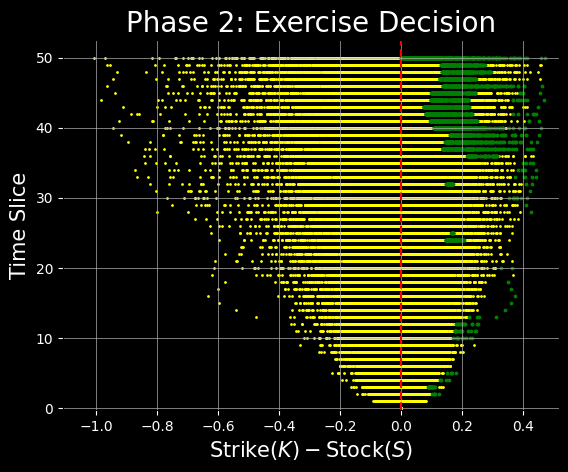

In [106]:
fig, ax = plt.subplots()
fig.set_facecolor('black')
ax.set_facecolor('black')
plot_frame_phase2(0,ax)
plt.show()

In [107]:
from matplotlib.animation import PillowWriter

In [108]:
metadata = dict(title='Movie', artist ='ayush_roy')
writer = PillowWriter(fps=10, metadata = metadata)

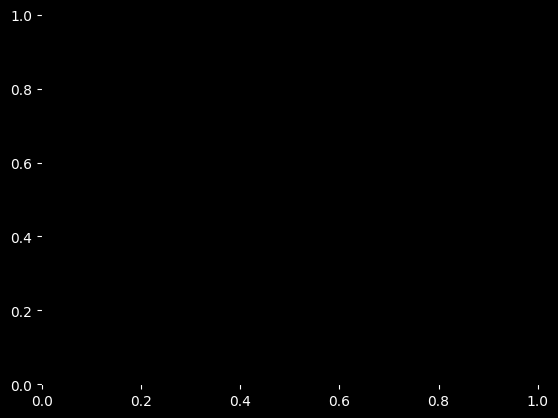

In [110]:
fig, ax = plt.subplots()
fig.set_facecolor('black')
ax.set_facecolor('black')

with writer.saving(fig, 'american_put_montecarlo.gif',100):
    #phase 1
    for i in range(0, 51):
        plot_frame_phase1(i, ax)
        writer.grab_frame()
        ax.clear()
    #phase 2
    for i in range(50, -1, -1):
        for j in range(0,3): #hold each frame here thrice
            plot_frame_phase2(i, ax)
            writer.grab_frame()
            ax.clear()

    